In [1]:
#Data Handling
import numpy as np
import pandas as pd

In [2]:
#Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Preprocessing Tools
from sklearn.preprocessing import OneHotEncoder, RobustScaler

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
#Machine Learning Models

In [5]:
from sklearn.decomposition import PCA
#Dimensionality Reduction

In [6]:
from sklearn.model_selection import train_test_split
#Train-Test Split

In [7]:
from sklearn.metrics import classification_report, accuracy_score
#Model Evaluation

In [8]:
from imblearn.over_sampling import SMOTE
#Handling Imbalanced Data

In [2]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [5]:
import pandas as pd
#Load Dataset
COL_NAMES = [
'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment',
'urgent','hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted',
'num_root','num_file_creations','num_shells','num_access_files','num_outbound_cmds',
'is_host_login','is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate',
'attack_class','difficulty_level'
]

train_path = "./data/KDDTrain+.txt"
test_path  = "./data/KDDTest+.txt"

df_train = pd.read_csv(train_path, names=COL_NAMES)
df_test  = pd.read_csv(test_path, names=COL_NAMES)

print("Train Shape:", df_train.shape)
print("Test Shape :", df_test.shape)

Train Shape: (125973, 43)
Test Shape : (22544, 43)


In [6]:
#Attack Mapping
def create_attack_mapping():
    return {
        'normal':'normal',
        'back':'DoS','land':'DoS','neptune':'DoS','pod':'DoS','smurf':'DoS','teardrop':'DoS',
        'satan':'Probe','ipsweep':'Probe','nmap':'Probe','portsweep':'Probe',
        'guess_passwd':'R2L','ftp_write':'R2L','imap':'R2L','multihop':'R2L',
        'buffer_overflow':'U2R','loadmodule':'U2R','perl':'U2R','rootkit':'U2R'
    }

attack_map = create_attack_mapping()

df_train['attack_category'] = df_train['attack_class'].map(attack_map)
df_test['attack_category']  = df_test['attack_class'].map(attack_map)

In [14]:
def create_attack_mapping():
    return {
        'normal':'Normal',

        'back':'DoS','land':'DoS','neptune':'DoS','pod':'DoS',
        'smurf':'DoS','teardrop':'DoS',

        'ipsweep':'Probe','nmap':'Probe','portsweep':'Probe','satan':'Probe',

        'ftp_write':'R2L','guess_passwd':'R2L','imap':'R2L',
        'multihop':'R2L','phf':'R2L','spy':'R2L','warezclient':'R2L',
        'warezmaster':'R2L',

        'buffer_overflow':'U2R','loadmodule':'U2R',
        'perl':'U2R','rootkit':'U2R'
    }#here cretae attack mappuing function

In [15]:
attack_map = create_attack_mapping()
#Apply Mapping
df_train['attack_category'] = df_train['attack_class'].map(attack_map)
df_test['attack_category']  = df_test['attack_class'].map(attack_map)

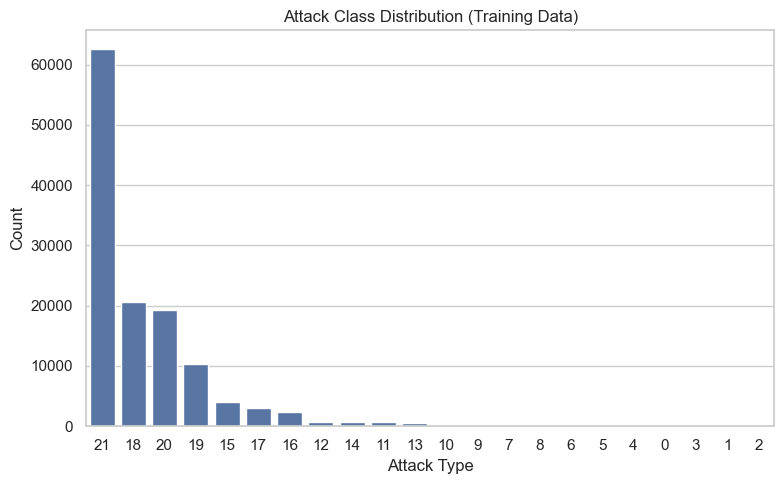

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_train, x="attack_class", order=df_train['attack_class'].value_counts().index)
plt.title("Attack Class Distribution (Training Data)")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [21]:
#Feature Engineering
def engineer_features(df):
    df = df.copy()

    df["total_bytes"] = df["src_bytes"] + df["dst_bytes"]
    
    df["byte_ratio"] = np.where(
        df["total_bytes"] == 0,
        0,
        df["src_bytes"] / df["total_bytes"]
    )

    df["byte_difference"] = abs(df["src_bytes"] - df["dst_bytes"])

    df["traffic_rate"] = np.where(
        df["duration"] == 0,
        df["count"],
        df["count"] / (df["duration"] + 1e-5)
    )

    df["error_flag"] = df["flag"].apply(
        lambda x: 1 if x in {"S0","S1","S2","S3","REJ"} else 0
    )
    return df

df_train = engineer_features(df_train)
df_test  = engineer_features(df_test)

In [24]:
train_encoded_df = pd.DataFrame(
    train_encoded,
    columns=encoded_cols,
    index=df_train.index
)

test_encoded_df = pd.DataFrame(
    test_encoded,
    columns=encoded_cols,
    index=df_test.index
)

In [25]:
df_train_encoded = pd.concat(
    [df_train.drop(columns=cat_cols), train_encoded_df],
    axis=1
)
df_test_encoded = pd.concat(
    [df_test.drop(columns=cat_cols), test_encoded_df],
    axis=1
)

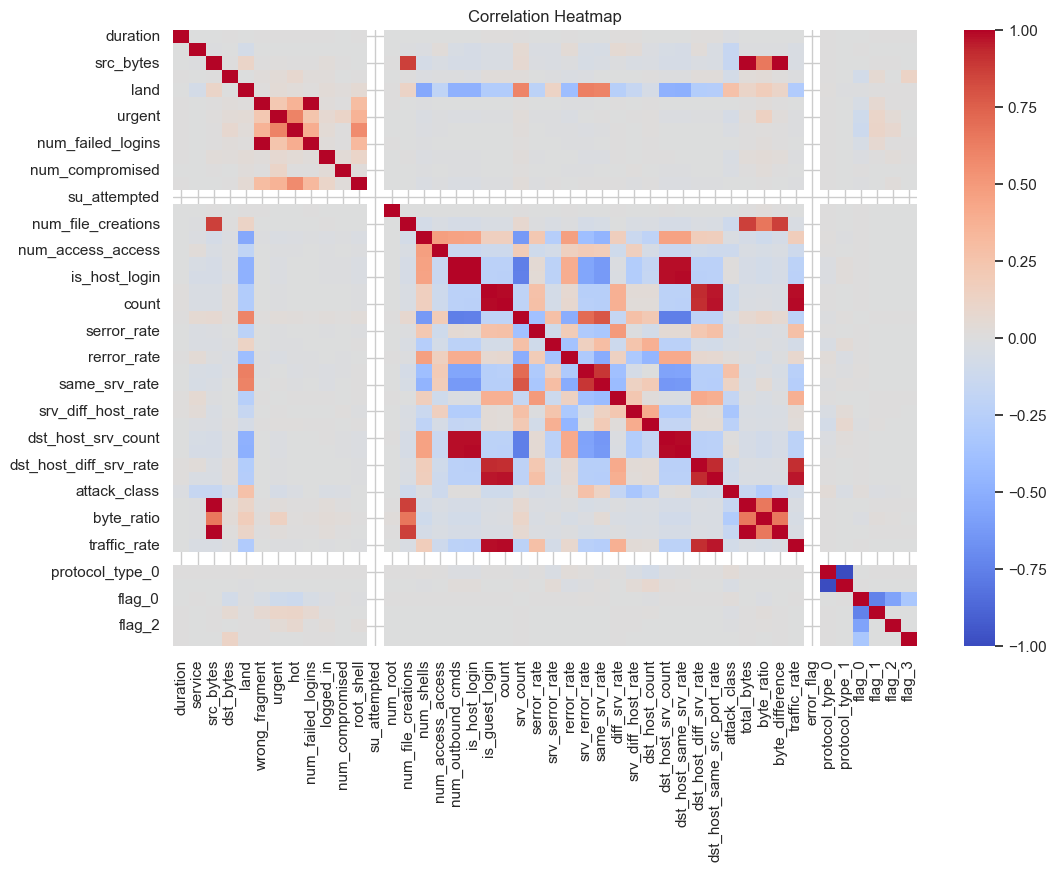

In [26]:
numeric_cols = df_train_encoded.select_dtypes(include=np.number).columns
#Correlation Heatmap
corr_matrix = df_train_encoded[numeric_cols].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [27]:
threshold = 0.95
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
#Remove Highly Correlated Features
drop_cols = [col for col in upper.columns if any(upper[col] > threshold)]
df_train_encoded.drop(columns=drop_cols, inplace=True)
df_test_encoded.drop(columns=drop_cols, inplace=True)
print("Removed Features:", drop_cols)

Removed Features: ['num_failed_logins', 'is_host_login', 'count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_same_src_port_rate', 'total_bytes', 'byte_difference', 'traffic_rate']


In [8]:
import pandas as pd

#Encode categorical features
categorical_cols = ['protocol_type', 'service', 'flag']

df_train_encoded = pd.get_dummies(df_train, columns=categorical_cols)
df_test_encoded  = pd.get_dummies(df_test, columns=categorical_cols)

print(df_train_encoded.columns)

Index(['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
       'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
       ...
       'flag_REJ', 'flag_RSTO', 'flag_RSTOS0', 'flag_RSTR', 'flag_S0',
       'flag_S1', 'flag_S2', 'flag_S3', 'flag_SF', 'flag_SH'],
      dtype='str', length=125)


In [85]:
#Exampleof feature engineering
df_train_encoded["byte_ratio"] = df_train_encoded["src_bytes"] / (df_train_encoded["dst_bytes"] + 1)

df_train_encoded["packet_total"] = (
    df_train_encoded["src_packets"] + df_train_encoded["dst_packets"]
    if "src_packets" in df_train_encoded.columns and "dst_packets" in df_train_encoded.columns
    else 0
)

print("New Features Created")

New Features Created


In [86]:
#Generic feature engineering
numeric_cols = df_train_encoded.select_dtypes(include=["int64","float64"]).columns

df_train_encoded["feature_sum"] = df_train_encoded[numeric_cols].sum(axis=1)
df_train_encoded["feature_mean"] = df_train_encoded[numeric_cols].mean(axis=1)

In [28]:
X_temp = df_train_encoded.drop(columns=['attack_class', 'attack_category'])
y_temp = df_train_encoded['attack_class']

In [29]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_temp = le.fit_transform(y_temp)

In [30]:
X_temp = X_temp.apply(pd.to_numeric, errors='coerce')
X_temp = X_temp.fillna(0)

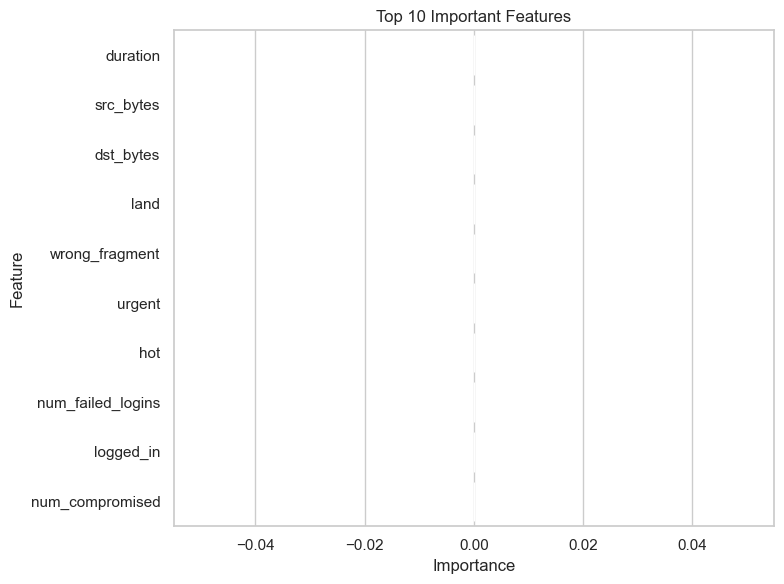

In [32]:
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

#Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
#Feature importance dataframe
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

#Plot
plt.figure(figsize=(8,6))
sns.barplot(
    data=importance_df.head(10),
    y="Feature",
    x="Importance"
)

plt.title("Top 10 Important Features")
plt.tight_layout()
plt.show()

In [10]:
#Remove difficulty column
df_train = df_train.iloc[:, :-1]
print("New shape after removing difficulty:", df_train.shape)

New shape after removing difficulty: (125973, 43)


In [15]:
X = df_train.iloc[:, :-1]   #All columns except last
y = df_train.iloc[:, -1]    #Last column is target
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (125973, 42)
y shape: (125973,)


In [16]:
y = y.apply(lambda x: 0 if x == "normal" else 1)
#Convert Attack Types to Binary
print(y.value_counts())

difficulty_level
1    125973
Name: count, dtype: int64


In [17]:
#Convert Categorical Features
X = pd.get_dummies(X)
print("Shape after encoding:", X.shape)

Shape after encoding: (125973, 145)


In [18]:
import numpy as np
#correlation removal
corr_matrix = X.corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
X = X.drop(columns=to_drop)

print("Dropped columns:", len(to_drop))
print("Shape after correlation removal:", X.shape)

Dropped columns: 10
Shape after correlation removal: (125973, 135)


In [19]:
from sklearn.preprocessing import StandardScaler
#Convert all column names to string (FIX)
X.columns = X.columns.astype(str)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaling successful!")

Scaling successful!


In [20]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)
print("After PCA:", X_pca.shape)

After PCA: (125973, 103)


In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)
print("Original shape:", X.shape)
print("After PCA shape:", X_pca.shape)

Original shape: (125973, 135)
After PCA shape: (125973, 103)


In [58]:
df_train_reduce = df_train_encoded.copy()
df_test_reduce = df_test_encoded.copy()

In [59]:
from sklearn.preprocessing import RobustScaler

exclude_cols = ['label','attack_class','difficulty_level','is_outlier']
#Select scaling features
scale_cols = df_train_reduce.select_dtypes(include=[np.number]).columns
scale_features = [c for c in scale_cols if c not in exclude_cols]
scaler = RobustScaler()

#Convert columns to float 
df_train_reduce[scale_features] = df_train_reduce[scale_features].astype(float)
df_test_reduce[scale_features] = df_test_reduce[scale_features].astype(float)

#Fitting scaler on training data only
df_train_reduce.loc[:, scale_features] = scaler.fit_transform(
    df_train_reduce[scale_features]
)

#Transform test data
df_test_reduce.loc[:, scale_features] = scaler.transform(
    df_test_reduce[scale_features]
)

print(df_train_reduce[scale_features].describe())

           duration     src_bytes     dst_bytes           land  \
count  125973.00000  1.259730e+05  1.259730e+05  125973.000000   
mean      287.14465  1.649375e+02  3.833162e+01       0.000198   
std      2604.51531  2.126932e+04  7.793157e+03       0.014086   
min         0.00000 -1.594203e-01  0.000000e+00       0.000000   
25%         0.00000 -1.594203e-01  0.000000e+00       0.000000   
50%         0.00000  0.000000e+00  0.000000e+00       0.000000   
75%         0.00000  8.405797e-01  1.000000e+00       0.000000   
max     42908.00000  4.999869e+06  2.538638e+06       1.000000   

       wrong_fragment         urgent            hot  num_failed_logins  \
count   125973.000000  125973.000000  125973.000000      125973.000000   
mean         0.022687       0.000111       0.204409           0.001222   
std          0.253530       0.014366       2.149968           0.045239   
min          0.000000       0.000000       0.000000           0.000000   
25%          0.000000       0.00000

In [64]:
# Separate features and target
X = df_train_encoded.drop(columns=['attack_class','difficulty_level'])
y = df_train_encoded['attack_class']

In [72]:
#Separate features and target correctly
X = df_train_encoded.drop(columns=['attack_category'])
y = df_train_encoded['attack_category']

In [74]:
print(type(y))
print(y.shape)

<class 'pandas.Series'>
(125973,)


In [77]:
y = df_train_encoded['attack_category'].astype(str)

In [80]:
#Remove rows where attack_category is NaN
df_train_encoded = df_train_encoded.dropna(subset=['attack_category'])
X = df_train_encoded.drop(columns=['attack_category'])
y = df_train_encoded['attack_category']
print(y.value_counts())

attack_category
normal    67343
DoS       45927
Probe     11656
R2L          79
U2R          52
Name: count, dtype: int64


In [81]:
#Ensure X is numeric
X = X.apply(pd.to_numeric, errors='coerce')

#Replace missing values
X = X.fillna(0)

print(X.shape)
print(y.shape)

(125057, 124)
(125057,)


In [82]:
from imblearn.over_sampling import SMOTE
#Applying SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("After SMOTE:", X_resampled.shape)
print(y_resampled.value_counts())

After SMOTE: (336715, 124)
attack_category
normal    67343
DoS       67343
Probe     67343
R2L       67343
U2R       67343
Name: count, dtype: int64


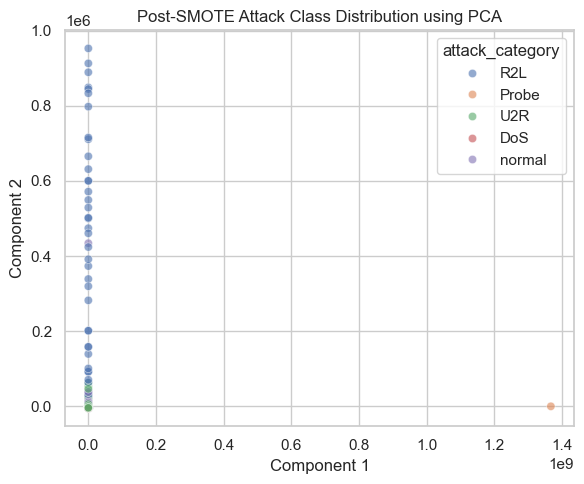

In [84]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

#hereReducing dataset size for visualization
sample_size = 5000

sample_idx = X_resampled.sample(sample_size, random_state=42).index
X_vis = X_resampled.loc[sample_idx]
y_vis = y_resampled.loc[sample_idx]

#PCA transformation
pca_model = PCA(n_components=2)
pca_features = pca_model.fit_transform(X_vis)

#Plot PCA scatter visualization
plt.figure(figsize=(6,5))

sns.scatterplot(
    x=pca_features[:,0],
    y=pca_features[:,1],
    hue=y_vis,
    alpha=0.6
)

plt.title("Post-SMOTE Attack Class Distribution using PCA")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.tight_layout()
plt.show()

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y,
    test_size=0.2,
    random_state=42
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (100778, 103)
Test shape: (25195, 103)


In [34]:
X = df_train_encoded.drop(columns=['label','attack_class','difficulty_level'], errors='ignore')
y = df_train_encoded['attack_class']

In [35]:
from sklearn.model_selection import train_test_split
#Features and target
X = df_train_encoded.drop(columns=['attack_class'], errors='ignore')
y = df_train_encoded['attack_class']
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (100778, 124)
Test shape: (25195, 124)


In [39]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
#Initialize Model

In [38]:
X = pd.get_dummies(
    X,
    columns=[col for col in ['protocol_type','service'] if col in X.columns],
    drop_first=True
)

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
#Import Model and Metrics

In [41]:
print(X.select_dtypes(include='object').columns)

Index(['attack_category'], dtype='str')


In [44]:
print(X_train.dtypes)

duration          int64
src_bytes         int64
dst_bytes         int64
land              int64
wrong_fragment    int64
                  ...  
flag_S1            bool
flag_S2            bool
flag_S3            bool
flag_SF            bool
flag_SH            bool
Length: 124, dtype: object


In [45]:
X = pd.get_dummies(X, drop_first=True)

In [46]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [47]:
#Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Train RandomForest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.999047430045644
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       185
           1       1.00      0.56      0.71         9
           2       0.00      0.00      0.00         0
           3       1.00      0.91      0.95        11
           4       1.00      1.00      1.00         1
           5       0.99      0.99      0.99       733
           6       0.50      0.33      0.40         3
           7       0.00      0.00      0.00         0
           9       1.00      1.00      1.00      8228
          10       0.98      0.99      0.99       313
          11       1.00      1.00      1.00     13422
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14       1.00      0.93      0.96        43
          15       1.00      1.00      1.00       573
          16       0.00      0.00      0.00         1
          17       1.00      1.00      1.00       738

In [52]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [53]:
rf_pred = rf_model.predict(X_test)

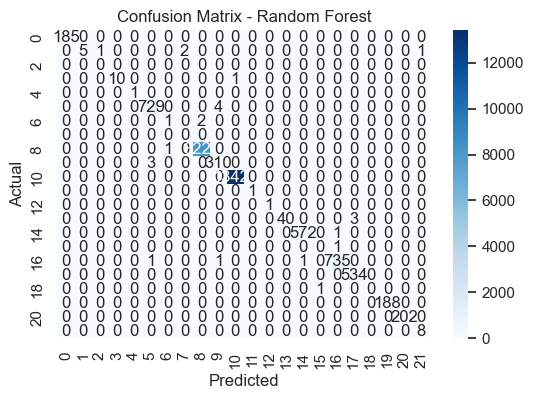

In [54]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)
#confusion-matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [87]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
#Models
log_model= LogisticRegression(max_iter=1000)
dt_model= DecisionTreeClassifier(random_state=42)
rf_model= RandomForestClassifier(n_estimators=100, random_state=42)
#Train models
log_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
print("Models Trained Successfully")

Models Trained Successfully


In [88]:
log_pred = log_model.predict(X_test)
dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
#herePredictions

In [89]:
from sklearn.metrics import accuracy_score, classification_report
#Evaluation Metrics
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

print("\nRandom Forest Report\n")
print(classification_report(y_test, rf_pred))

Logistic Regression Accuracy: 0.8413971025997221
Decision Tree Accuracy: 0.9989283588013494
Random Forest Accuracy: 0.999047430045644

Random Forest Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       185
           1       1.00      0.56      0.71         9
           2       0.00      0.00      0.00         0
           3       1.00      0.91      0.95        11
           4       1.00      1.00      1.00         1
           5       0.99      0.99      0.99       733
           6       0.50      0.33      0.40         3
           7       0.00      0.00      0.00         0
           9       1.00      1.00      1.00      8228
          10       0.98      0.99      0.99       313
          11       1.00      1.00      1.00     13422
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14       1.00      0.93      0.96        43
          15       1.00      1.0

In [90]:
import pandas as pd
#Model Comparison Table
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.841397
1        Decision Tree  0.998928
2        Random Forest  0.999047


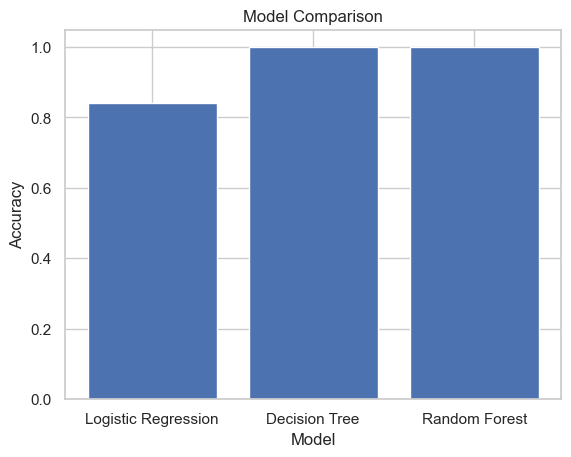

In [91]:
import matplotlib.pyplot as plt
#Accuracy Visualization
plt.bar(results["Model"], results["Accuracy"])
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()